In [ ]:
import random
import torch

random.seed(42)
torch.manual_seed(42)

In [ ]:
with open("TrainingNames.txt",'r',encoding='utf-8') as f:
    names=f.read()

In [ ]:
names

'Aabha, Aadarshita, Aadesh, Aadhira, Aadhya, Aadi, Aadish, Aaditri, Aadvik, Aadyant, Aagamya, Aahaan, Aahuti, Aakankshi, Aakarsh, Aakshara, Aalaya, Aali, Aaliya, Aamod, Aanandita, Aanika, Aanshi, Aanshul, Aapt, Aaratrika, Aarika, Aarit, Aarnav, Aarpit, Aarshi, Aaryahi, Aaryav, Aasmi, Aasrita, Aatmaja, Aavani, Aavesh, Aavya, Aayra, Aayraansh, Aayusman, Abhaya, Abhayananda, Abheer, Abheek, Abhigyan, Abhijat, Abhilesh, Abhimanyu, Abhira, Abhiraj, Abhiram, Abhiruchi, Abhivyakti, Abhra, Achala, Achintya, Achira, Adarshini, Adhish, Adhita, Adhiyajna, Adhritesh, Adhyayan, Adhyatma, Adika, Adinath, Adish, Adishree, Aditesh, Aditeya, Adrika, Advaya, Advika, Aesha, Aghanya, Agney, Agnivesh, Agnija, Agnishikha, Agnimitra, Ahalya, Ahanaaya, Ahar, Ahlad, Ahladita, Ainesh, Aira, Airavat, Aishani, Aishika, Aishita, Ajitaabha, Ajitesh, Ajmani, Akarshika, Akhand, Akhilesh, Akhilaansh, Akhilendra, Akritiika, Akroor, Akshansh, Akshara, Akshat, Akshayansh, Akshobhya, Akul, Alakh, Alankrita, Alapan, Alarka

In [ ]:
import torch
import torch.nn as nn

class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_size=64, hidden_size=128):
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size

        #  Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embed_size)

        #  Vanilla RNN Layer
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)

        # Fully Connected (Output) Layer
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        out, hidden = self.rnn(embedded, hidden)

        # Predict the next character for every time step
        logits = self.fc(out)
        return logits, hidden

In [ ]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size=64, hidden_size=128):
        super(BiLSTM, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(vocab_size, embed_size)

        # Bidirectional is set to True
        self.lstm = nn.LSTM(embed_size, hidden_size,num_layers=2, batch_first=True, bidirectional=True)

        #Adding Dropout
        self.dropout = nn.Dropout(0.5)

        # Multiply hidden_size by 2 because we concatenate forward and backward passes
        self.fc = nn.Linear(hidden_size * 2, vocab_size)

    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        out, hidden = self.lstm(embedded, hidden)

        out = self.dropout(out)

        # Concatenate forward and backward hidden states

        logits = self.fc(out)
        return logits, hidden

In [ ]:
import torch.nn.functional as F

class AttentionRNN(nn.Module):
    def __init__(self, vocab_size, embed_size=64, hidden_size=128):
        super(AttentionRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)

        # Basic Attention Layer (maps hidden state to a single score)
        self.attention = nn.Linear(hidden_size, 1)

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        out, hidden = self.rnn(embedded, hidden)

        # Calculate Attention Weights
        attn_scores = self.attention(out)          # Shape: (batch, seq_len, 1)
        attn_weights = F.softmax(attn_scores, dim=1) # Normalize over sequence length

        # Apply weights to the RNN output
        context = out + (out * attn_weights)

        logits = self.fc(context)
        return logits, hidden

In [ ]:
def count_param(model):
    total_params = 0

    # Loop through every single weight and bias (parameter) in the model
    for p in model.parameters():

        # Check if this parameter is actually being trained
        if p.requires_grad == True:

            # p.numel() counts the number of elements (numbers) inside that parameter
            total_params = total_params + p.numel()

    return total_params

In [ ]:

vocab_size = 26
model1 = VanillaRNN(vocab_size)
print(f"Vanilla RNN Model Parameters: {count_param(model1)}")

Vanilla RNN Model Parameters: 29850


In [ ]:
vocab_size = 26
model2 = BiLSTM(vocab_size = vocab_size,embed_size=64,hidden_size=64)
print(f"BiLSTM Model Parameters: {count_param(model2)}")

Vanilla RNN Model Parameters: 170906


In [ ]:
vocab_size = 26
model2 = BiLSTM(vocab_size = vocab_size,embed_size=64,hidden_size=64)
print(f"BiLSTM Model Parameters: {count_param(model2)}")

In [ ]:
model3 = AttentionRNN(vocab_size = vocab_size,embed_size=64,hidden_size=128)
vocab_size = 26
print(f"Attention RNN Model Parameters: {count_param(model3)}")

Attention RNN Model Parameters: 29979


Preprocessing step of dataset

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

#replace with space any accidental newlines
names = names.replace('\n',' ')

names = names.split(',')

clean_names = []
for i in names:
  clean_name = i.strip().lower()
  #Add valid string
  if(len(clean_name)>0):
    clean_names.append(clean_name)

In [ ]:
names_list = clean_names
print(len(names_list))

1431


In [ ]:
for i in names_list:
  print(i)

aabha
aadarshita
aadesh
aadhira
aadhya
aadi
aadish
aaditri
aadvik
aadyant
aagamya
aahaan
aahuti
aakankshi
aakarsh
aakshara
aalaya
aali
aaliya
aamod
aanandita
aanika
aanshi
aanshul
aapt
aaratrika
aarika
aarit
aarnav
aarpit
aarshi
aaryahi
aaryav
aasmi
aasrita
aatmaja
aavani
aavesh
aavya
aayra
aayraansh
aayusman
abhaya
abhayananda
abheer
abheek
abhigyan
abhijat
abhilesh
abhimanyu
abhira
abhiraj
abhiram
abhiruchi
abhivyakti
abhra
achala
achintya
achira
adarshini
adhish
adhita
adhiyajna
adhritesh
adhyayan
adhyatma
adika
adinath
adish
adishree
aditesh
aditeya
adrika
advaya
advika
aesha
aghanya
agney
agnivesh
agnija
agnishikha
agnimitra
ahalya
ahanaaya
ahar
ahlad
ahladita
ainesh
aira
airavat
aishani
aishika
aishita
ajitaabha
ajitesh
ajmani
akarshika
akhand
akhilesh
akhilaansh
akhilendra
akritiika
akroor
akshansh
akshara
akshat
akshayansh
akshobhya
akul
alakh
alankrita
alapan
alarka
alay
alekhya
alhad
alindra
alipta
alkaaya
alokita
alpa
alpana
alpesh
alvira
amala
amanpreet
amardeep
amarendra
a

In [ ]:
#find unique characters
all_chars = set("".join(names_list))
all_chars.add("<EOS>") # add end of sequence token
#map characters to numbers
char_to_int = {char:i for i,char in enumerate(all_chars)}
int_to_char = {i:char for i,char in enumerate(all_chars)}
vocab_size = len(all_chars)
print(vocab_size)

26


In [ ]:
def name_to_tensor(name):
  #convert names to list of numbers
  n_i = [char_to_int[c] for c in name]
  n_i.append(char_to_int["<EOS>"]) #add end of sequence token at the end
  return torch.tensor(n_i)

In [ ]:
import random

#Splitting the data
random.shuffle(names_list)
splitindex = int(len(names_list)*0.9)
train = names_list[:splitindex]
val = names_list[splitindex:]

print(f"Training set size: {len(train)}")
print(f"Validation set size: {len(val)}")

Training set size: 1287
Validation set size: 144


In [ ]:
model1 = VanillaRNN(vocab_size = vocab_size,embed_size=64,hidden_size=128)
model2 = BiLSTM(vocab_size = vocab_size,embed_size=64,hidden_size=64)
model3 = AttentionRNN(vocab_size = vocab_size,embed_size=64,hidden_size=128)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model1.parameters(),lr=0.001)
optimizer2 = optim.Adam(model2.parameters(),lr=0.001)
optimizer3 = optim.Adam(model3.parameters(),lr=0.001)

Training of VanillaRNN  model

In [ ]:
import torch
import random

# Lower epochs to 50, because 1 epoch now processes the ENTIRE dataset!
epochs = 50
best_val_loss = float('inf')
train_loss_history_rnn = []
val_loss_history_rnn = []
epoch_history_rnn = []
patience = 5
patience_counter = 0

print("Starting Model 1 Training...")

for epoch in range(1, epochs + 1):
    model1.train()
    epoch_train_loss = 0


    random.shuffle(train)

    for name in train: # Loop through every name in the dataset
        name_tensor = name_to_tensor(name)
        input_seq = name_tensor[:-1].unsqueeze(0)
        target_seq = name_tensor[1:]


        optimizer1.zero_grad()

        logits, hidden = model1(input_seq)
        logits = logits.squeeze(0)
        loss = criterion(logits, target_seq)
        loss.backward()

        optimizer1.step()
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train)

    # Validation step
    model1.eval()
    val_loss_total = 0

    with torch.no_grad():
        for _ in range(50):
            val_name = random.choice(val)
            val_tensor = name_to_tensor(val_name)
            val_input = val_tensor[:-1].unsqueeze(0)
            val_target = val_tensor[1:]

            # --- FIX 1: MATCHING MODELS ---
            val_logits, val_hidden = model1(val_input)

            val_loss_total += criterion(val_logits.squeeze(0), val_target).item()

    avg_val_loss = val_loss_total / 50

    print(f"Epoch {epoch}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    epoch_history_rnn.append(epoch)
    train_loss_history_rnn.append(avg_train_loss)
    val_loss_history_rnn.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save the best model!
        torch.save(model1.state_dict(), 'best_model1.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            # Restore the best model!
            model1.load_state_dict(torch.load('best_model1.pth'))
            break

Starting Model 1 Training...
Epoch 1/50 | Train Loss: 2.1341 | Val Loss: 1.9778
Epoch 2/50 | Train Loss: 1.9188 | Val Loss: 1.9245
Epoch 3/50 | Train Loss: 1.8356 | Val Loss: 2.0015
Epoch 4/50 | Train Loss: 1.7689 | Val Loss: 1.9627
Epoch 5/50 | Train Loss: 1.7141 | Val Loss: 1.9203
Epoch 6/50 | Train Loss: 1.6584 | Val Loss: 1.7478
Epoch 7/50 | Train Loss: 1.6171 | Val Loss: 1.7954
Epoch 8/50 | Train Loss: 1.5639 | Val Loss: 1.7038
Epoch 9/50 | Train Loss: 1.5203 | Val Loss: 1.9077
Epoch 10/50 | Train Loss: 1.4820 | Val Loss: 1.9096
Epoch 11/50 | Train Loss: 1.4444 | Val Loss: 1.8779
Epoch 12/50 | Train Loss: 1.4120 | Val Loss: 1.9543
Epoch 13/50 | Train Loss: 1.3806 | Val Loss: 2.1240
Early stopping at epoch 13


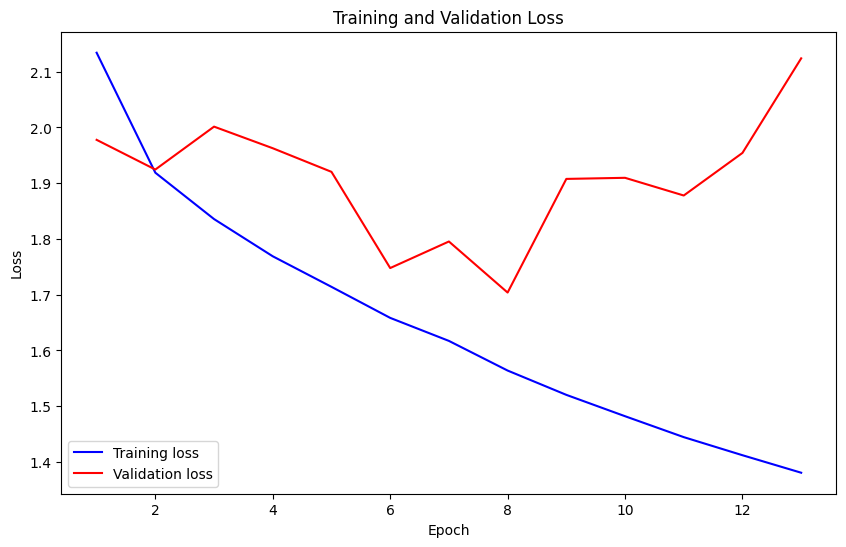

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(epoch_history_rnn,train_loss_history_rnn,label="Training loss",color = 'blue')
plt.plot(epoch_history_rnn,val_loss_history_rnn,label="Validation loss",color = 'red')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(False)
plt.show()


Training of model2

In [ ]:
import torch
import random

epochs = 50
best_val_loss = float('inf')
train_loss_history_bilstm = []
val_loss_history_bilstm = []
epoch_history_bilstm = []
patience = 5
patience_counter = 0

print("Starting Model 2 Training...")

for epoch in range(1, epochs + 1):
    model2.train()
    epoch_train_loss = 0


    random.shuffle(train)

    for name in train: # Loop through every name in the dataset
        name_tensor = name_to_tensor(name)
        input_seq = name_tensor[:-1].unsqueeze(0)
        target_seq = name_tensor[1:]


        optimizer2.zero_grad()

        logits, hidden = model2(input_seq)
        logits = logits.squeeze(0)
        loss = criterion(logits, target_seq)
        loss.backward()

        optimizer2.step()
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train)

    #Validation step
    model2.eval()
    val_loss_total = 0

    with torch.no_grad():
        for _ in range(50):
            val_name = random.choice(val)
            val_tensor = name_to_tensor(val_name)
            val_input = val_tensor[:-1].unsqueeze(0)
            val_target = val_tensor[1:]


            val_logits, val_hidden = model2(val_input)

            val_loss_total += criterion(val_logits.squeeze(0), val_target).item()

    avg_val_loss = val_loss_total / 50

    print(f"Epoch {epoch}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    epoch_history_bilstm.append(epoch)
    train_loss_history_bilstm.append(avg_train_loss)
    val_loss_history_bilstm.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save the best model!
        torch.save(model2.state_dict(), 'best_model2.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            # Restore the best model!
            model2.load_state_dict(torch.load('best_model2.pth'))
            break

Starting Model 2 Training...
Epoch 1/50 | Train Loss: 0.8454 | Val Loss: 0.0888
Epoch 2/50 | Train Loss: 0.0784 | Val Loss: 0.0473
Epoch 3/50 | Train Loss: 0.0199 | Val Loss: 0.0139
Epoch 4/50 | Train Loss: 0.0100 | Val Loss: 0.0105
Epoch 5/50 | Train Loss: 0.0056 | Val Loss: 0.0063
Epoch 6/50 | Train Loss: 0.0035 | Val Loss: 0.0005
Epoch 7/50 | Train Loss: 0.0021 | Val Loss: 0.0002
Epoch 8/50 | Train Loss: 0.0012 | Val Loss: 0.0033
Epoch 9/50 | Train Loss: 0.0062 | Val Loss: 0.0071
Epoch 10/50 | Train Loss: 0.0033 | Val Loss: 0.0006
Epoch 11/50 | Train Loss: 0.0011 | Val Loss: 0.0046
Epoch 12/50 | Train Loss: 0.0022 | Val Loss: 0.0017
Early stopping at epoch 12


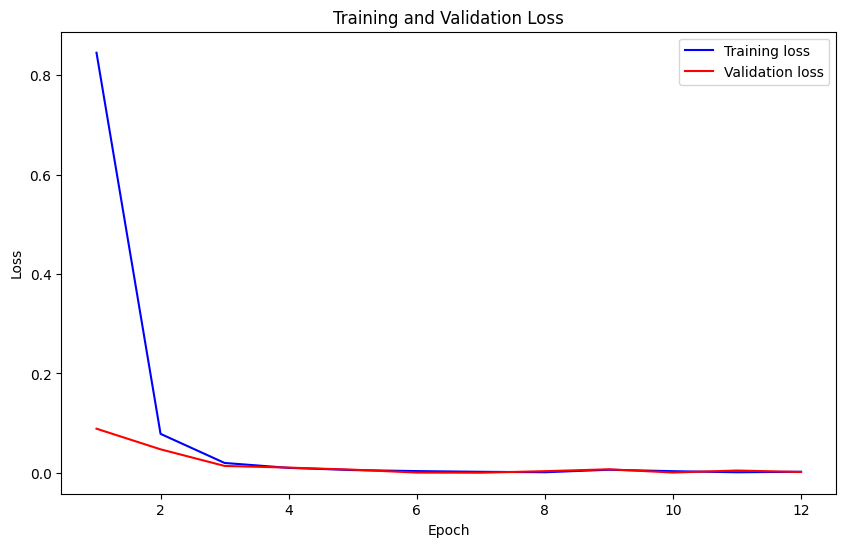

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(epoch_history_bilstm,train_loss_history_bilstm,label="Training loss",color = 'blue')
plt.plot(epoch_history_bilstm,val_loss_history_bilstm,label="Validation loss",color = 'red')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(False)
plt.show()


Training of model3

In [ ]:
import torch
import random


epochs = 50
best_val_loss = float('inf')
train_loss_history = []
val_loss_history = []
epoch_history = []
patience = 5
patience_counter = 0

print("Starting Model 3 Training...")

for epoch in range(1, epochs + 1):
    model3.train()
    epoch_train_loss = 0


    random.shuffle(train)

    for name in train: # Loop through every name in the dataset
        name_tensor = name_to_tensor(name)
        input_seq = name_tensor[:-1].unsqueeze(0)
        target_seq = name_tensor[1:]


        optimizer3.zero_grad()

        logits, hidden = model3(input_seq)
        logits = logits.squeeze(0)
        loss = criterion(logits, target_seq)
        loss.backward()

        optimizer3.step()
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train)

    #Validation step
    model3.eval()
    val_loss_total = 0

    with torch.no_grad():
        for _ in range(50):
            val_name = random.choice(val)
            val_tensor = name_to_tensor(val_name)
            val_input = val_tensor[:-1].unsqueeze(0)
            val_target = val_tensor[1:]


            val_logits, val_hidden = model3(val_input)

            val_loss_total += criterion(val_logits.squeeze(0), val_target).item()

    avg_val_loss = val_loss_total / 50

    print(f"Epoch {epoch}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    epoch_history.append(epoch)
    train_loss_history.append(avg_train_loss)
    val_loss_history.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save the best model!
        torch.save(model3.state_dict(), 'best_model3.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            # Restore the best model!
            model3.load_state_dict(torch.load('best_model3.pth'))
            break

Starting Model 3 Training...
Epoch 1/50 | Train Loss: 2.0906 | Val Loss: 2.0301
Epoch 2/50 | Train Loss: 1.8645 | Val Loss: 1.8514
Epoch 3/50 | Train Loss: 1.7700 | Val Loss: 1.8834
Epoch 4/50 | Train Loss: 1.6894 | Val Loss: 1.6714
Epoch 5/50 | Train Loss: 1.6227 | Val Loss: 1.7949
Epoch 6/50 | Train Loss: 1.5652 | Val Loss: 1.6936
Epoch 7/50 | Train Loss: 1.5092 | Val Loss: 1.6149
Epoch 8/50 | Train Loss: 1.4634 | Val Loss: 1.7044
Epoch 9/50 | Train Loss: 1.4167 | Val Loss: 1.6940
Epoch 10/50 | Train Loss: 1.3732 | Val Loss: 1.6176
Epoch 11/50 | Train Loss: 1.3388 | Val Loss: 1.7395
Epoch 12/50 | Train Loss: 1.3005 | Val Loss: 1.8662
Early stopping at epoch 12


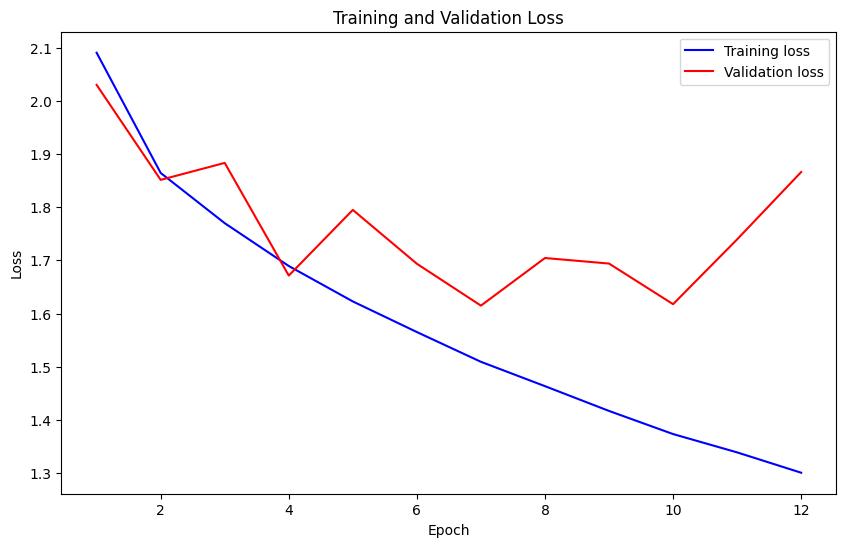

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(epoch_history,train_loss_history,label="Training loss",color = 'blue')
plt.plot(epoch_history,val_loss_history,label="Validation loss",color = 'red')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(False)
plt.show()


In [ ]:
import torch
import torch.nn.functional as F
import random


#function to generate nmaes using trained model
def generate_names(model,num_names,char_to_int,int_to_char,max_length = 15,temperature = .8):
  model.eval()
  gen_list = [] # to store our names in this list
  #excluding <EOS> token so that the name does not start with it
  val_st_char = [char for char in char_to_int.keys() if char!= '<EOS>']
  with torch.no_grad():
    for _ in range(num_names):
      st_char = random.choice(val_st_char)
      gen_char = [st_char]
      hidden = None # reset hidden state after each name
      curr_char_int = char_to_int[st_char] #format start letter fpr pytorch
      curr_input = torch.tensor([[curr_char_int]])
      #character generation
      for _ in range(max_length-1):
        logits, hidden = model(curr_input,hidden)
        last_char_pred = logits[0,-1,:]/temperature #pred for last letter
        probabilities = F.softmax(last_char_pred,dim=0) #convert to probabilities
        next_char_int = torch.multinomial(probabilities,1).item()
        next_char = int_to_char[next_char_int]
        if next_char == '<EOS>':
          break
        gen_char.append(next_char)
        curr_input = torch.tensor([[next_char_int]])
      f_name = "".join(gen_char)
      gen_list.append(f_name.capitalize())
  return gen_list



In [ ]:
model1.load_state_dict(torch.load('/content/best_model1.pth'))
model1.eval()

print("Generating 10 new names")
new_names_rnn = generate_names(model1,10,char_to_int,int_to_char,temperature=0.8)
for i in new_names_rnn:
  print(i)

Generating 10 new names
Rahma
Pracha
Havishi
Shaina
Pushan
Virabh
Pravesh
Amrupal
Lajun
Ojas


In [ ]:
import torch
import torch.nn.functional as F
import random

def generate_names_bilstm(model, num_names, char_to_int, int_to_char, max_length=15, temperature=0.5):
    model.eval()
    gen_list = []

    # Valid starting characters (excluding <EOS>)
    val_st_char = [char for char in char_to_int.keys() if char != '<EOS>']

    with torch.no_grad():
        for _ in range(num_names):
            st_char = random.choice(val_st_char)

            # Keep a growing list of the integers for the whole name
            sequence_ints = [char_to_int[st_char]]

            for _ in range(max_length - 1):
                #  Feed the entire sequence built so far into the model
                # Shape: (1, current_sequence_length)
                curr_input = torch.tensor([sequence_ints])

                #  Pass it through the model (Notice we do NOT pass 'hidden')
                logits, _ = model(curr_input)

                # Grab the prediction for the VERY LAST letter in the sequence
                last_char_pred = logits[0, -1, :] / temperature

                # If we have at least 1 letter, penalize the model for picking it again
                if len(sequence_ints) >= 1:
                    prev_char_int = sequence_ints[-1]
                    # Subtract a massive number from the score of the letter we just used
                    last_char_pred[prev_char_int] -= 5.0


                # If the name is less than 5 letters long, make <EOS> impossible to pick
                if len(sequence_ints) < 5:
                    eos_index = char_to_int['<EOS>']
                    last_char_pred[eos_index] = -1e9 # Set probability to effectively zero


                # Find the top 10 highest probability characters to prevent gibberish
                top_k = 10
                top_k_probs, top_k_indices = torch.topk(last_char_pred, top_k)

                # Convert to probabilities and sample the next letter
                probabilities = F.softmax(top_k_probs, dim=0)

                # Pick from ONLY the top 10 choices
                choice_idx = torch.multinomial(probabilities, 1).item()
                next_char_int = top_k_indices[choice_idx].item()
                next_char = int_to_char[next_char_int]

                if next_char == '<EOS>':
                    break

                #  Add the new integer to our sequence list for the next loop
                sequence_ints.append(next_char_int)

            # Convert the final list of integers back into a string
            f_name = "".join([int_to_char[i] for i in sequence_ints])

            # Capitalize the first letter so it looks like a real name!
            gen_list.append(f_name.capitalize())

    return gen_list

In [ ]:
model2.load_state_dict(torch.load('/content/best_model2.pth'))
model2.eval()

print("Generating 10 new names")
new_names_bilstm = generate_names_bilstm(model2,10,char_to_int,int_to_char,temperature=0.8)
for i in new_names_bilstm:
  print(i)

Generating 10 new names
Zdosd
Geget
Uiqzu
Azdgh
Chogh
Edege
Wzfik
Pitog
Wabiz
Mozdo


In [ ]:
import torch.nn.functional as F

def generate_names_attention(model, num_names, char_to_int, int_to_char, max_length=15, temperature=0.8):
    model3.eval()
    gen_list = []

    # Valid starting characters (excluding <EOS>)
    val_st_char = [char for char in char_to_int.keys() if char != '<EOS>']

    with torch.no_grad():
        for _ in range(num_names):
            st_char = random.choice(val_st_char)
            sequence_ints = [char_to_int[st_char]]

            for _ in range(max_length - 1):
                #  Feed the entire sequence so attention can look at all past letters
                curr_input = torch.tensor([sequence_ints])

                # We don't need to pass hidden, let the RNN build it fresh over the sequence
                logits, _ = model3(curr_input)

                # Grab the prediction for the very last letter
                last_char_pred = logits[0, -1, :] / temperature


                # Stop it from repeating the exact same letter it just used
                if len(sequence_ints) >= 1:
                    prev_char_int = sequence_ints[-1]
                    last_char_pred[prev_char_int] -= 3.0 # Heavy penalty


                # Prevent names shorter than 3 letters
                if len(sequence_ints) < 3:
                    eos_index = char_to_int['<EOS>']
                    last_char_pred[eos_index] = -1e9 # Impossible to pick <EOS>


                # Only pick from the top 10 most logical next letters
                top_k = 10
                top_k_probs, top_k_indices = torch.topk(last_char_pred, top_k)

                # Convert to probabilities and sample
                probabilities = F.softmax(top_k_probs, dim=0)
                choice_idx = torch.multinomial(probabilities, 1).item()

                # Map back to the actual character integer
                next_char_int = top_k_indices[choice_idx].item()
                next_char = int_to_char[next_char_int]

                if next_char == '<EOS>':
                    break

                sequence_ints.append(next_char_int)

            # Build string and capitalize
            f_name = "".join([int_to_char[i] for i in sequence_ints])
            gen_list.append(f_name.capitalize())

    return gen_list

In [ ]:
model3.load_state_dict(torch.load('/content/best_model3.pth'))
model3.eval()
print("Generating 10 new names")
new_names = generate_names_attention(model3,10,char_to_int,int_to_char,temperature=0.8)
for i in new_names:
  print(i)

Generating 10 new names
Qayun
Jai
Vikul
Yashi
Deepa
Gunal
Omani
Tajan
Gopa
Isha


In [ ]:
def evaluate_model(generate_names,training_names):
  total_gen = len(generate_names)
  training_set = training_names
  #Calculate novelty rate
  novel_count = 0
  for i in generate_names:
    if i not in training_set:
      novel_count += 1
  novelty_rate = (novel_count/total_gen)*100

  #Calculate diversity
  uniq_gen_names = set(generate_names) #remove duplicates
  diversity_score = len(uniq_gen_names)/total_gen
  return novelty_rate,diversity_score

This is the novelty and diversity for model1(VanillaRNN)

In [ ]:
print("Calculating metrics")
novelty,diversity = evaluate_model(new_names_rnn,names_list)

print(f"Novelty Rate: {novelty:.2f}%")
print(f"Diversity Score: {diversity:.4f}")

Calculating metrics
Novelty Rate: 100.00%
Diversity Score: 1.0000


For model2(BiLSTM)

In [ ]:
print("Calculating metrics")
novelty,diversity = evaluate_model(new_names_bilstm,names_list)

print(f"Novelty Rate: {novelty:.2f}%")
print(f"Diversity Score: {diversity:.4f}")

Calculating metrics
Novelty Rate: 100.00%
Diversity Score: 1.0000


For model3(AttentionRNN)

In [ ]:
print("Calculating metrics")
novelty,diversity = evaluate_model(new_names,names_list)

print(f"Novelty Rate: {novelty:.2f}%")
print(f"Diversity Score: {diversity:.4f}")

Calculating metrics
Novelty Rate: 100.00%
Diversity Score: 1.0000
